# Notebook 03 — Full Analysis & Visualisation

This notebook produces the **tables and figures for the final report**. It loads both Phase 1 and Phase 2 results from disk, computes all metrics, and renders the plots.

Logic stays in `src/evaluation/` (`metrics.py`, `quantitative.py`, `qualitative.py`). This notebook only orchestrates and visualises.

**Three-way analytical framework** — every plot maps onto one of the three lenses defined in the report:

| Lens | Evidence in this notebook |
|------|---------------------------|
| Quantitative outcomes | Sections 2–4 |
| Pragmatic adaptation  | Section 5 (LLM-judge per-turn scores) |
| Scripted imitation    | Section 6 (cosine similarity vs few-shot examples, Phase 2 only) |
| Genuine reasoning     | Section 7 (CoT structural analysis) |



> **Prerequisites:** a completed Phase 1 run AND a completed Phase 2 run. Set the two run IDs below.

## 0. Setup

In [1]:
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)

Project root: /Users/alessandro/Progetti/NLP


In [2]:
import json
import matplotlib.ticker as mticker
from pathlib import Path
from dataclasses import asdict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from src.evaluation.quantitative import evaluate_run, summarise_run
from src.evaluation.qualitative  import analyse_cot, compute_imitation_similarity
from src.logging.transcript_logger import TranscriptLogger
from src.social_learning.prompt_updater import PromptUpdater

# ── Vintage Cream-Polarized style ─────────────────────────────────────────────
# Sfondo pergamena calda, palette anni '70 polarizzata caldo/freddo
BG         = "#fef9f0"   # carta crema calda
PANEL      = "#f5ede0"   # area plot leggermente più intensa
INK        = "#1e1510"   # inchiostro quasi-nero caldo
GRID_C     = "#e5dace"   # griglia beige tenue

RETRO_PALETTE = [
    "#c0392b",   # rosso terracotta   – Phase 1
    "#1a6b8a",   # blu petrolio       – Phase 2
    "#d4a017",   # giallo senape      – riferimento / accent
    "#2e8b7a",   # verde giada        – buyer / terzo colore
    "#c87941",   # terra di Siena     – extra
    "#7b5ea7",   # viola antico       – extra
]

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    "#c5b89a",
    "axes.labelcolor":   INK,
    "axes.titlecolor":   INK,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        GRID_C,
    "grid.linewidth":    0.6,
    "grid.linestyle":    "--",
    "xtick.color":       "#5c4a36",
    "ytick.color":       "#5c4a36",
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "text.color":        INK,
    "legend.facecolor":  "#fef5e7",
    "legend.edgecolor":  "#c5b89a",
    "legend.fontsize":   9,
    "font.family":       "serif",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "figure.dpi":        130,
    "savefig.facecolor": BG,
    "savefig.bbox":      "tight",
})
sns.set_palette(RETRO_PALETTE)
sns.set_style("ticks", {
    "axes.facecolor":   PANEL,
    "grid.color":       GRID_C,
    "axes.edgecolor":   "#c5b89a",
    "figure.facecolor": BG,
})

FIG_DIR = Path("data/results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

PHASE1_RUN_ID = "full_phase1"
PHASE2_RUN_ID = "full_phase2"

PHASE1_DIR = Path("data/raw") / PHASE1_RUN_ID
PHASE2_DIR = Path("data/raw") / PHASE2_RUN_ID
for d, label in [(PHASE1_DIR, "Phase 1"), (PHASE2_DIR, "Phase 2")]:
    if d.exists():
        print(f"{label}: {d}  ({len(list(d.glob('*.json')))} sessions)")
    else:
        print(f"{label}: MISSING -> {d}")

print("\nVintage Cream-Polarized style loaded ✓")

Phase 1: data/raw/full_phase1  (80 sessions)
Phase 2: data/raw/full_phase2  (80 sessions)

Vintage Cream-Polarized style loaded ✓


## 1. Load all session metrics into a single dataframe

`evaluate_run()` parses every JSON in a run directory and returns one `SessionMetrics` per session — all numeric, no API calls.

In [3]:
p1 = evaluate_run(str(PHASE1_DIR))
p2 = evaluate_run(str(PHASE2_DIR)) if PHASE2_DIR.exists() else []

df = pd.DataFrame([asdict(s) for s in (p1 + p2)])
df["is_deal"] = (df["outcome"] == "deal").astype(int)
print(f"Total sessions: {len(df)}  (P1={len(p1)}, P2={len(p2)})")
df.tail()

Total sessions: 160  (P1=80, P2=80)


,session_id,config,phase,outcome,final_price,bug_disclosed,bug_discovered,turns,avg_message_length,vocabulary_size,seller_concession_count,buyer_concession_count,llm_judge_scores,imitation_similarity,is_deal
155,15c02ba6-0c24-427c-8ac6-ce1ebaac1070,C,2,deal,7500.0,True,True,2,64.0,130,1,0,[],None,1
156,92597470-e200-41e0-ae61-5469b736313a,C,2,deal,7500.0,True,True,2,62.0,113,2,0,[],None,1
157,a1054197-5bc1-4e9e-ab01-3de1d3189be1,D,2,deal,7500.0,True,True,4,63.2,185,2,0,[],None,1
158,d3a27f61-5a8c-4aa1-be97-c2311050011c,A,2,deal,7000.0,True,True,4,66.4,182,3,1,[],None,1
159,870ed20a-b3a1-4698-a16d-2d5736429e31,C,2,deal,7500.0,True,True,4,64.6,185,2,0,[],None,1


## 2. Aggregated summary table — Phase 1 vs Phase 2 per config

This is the central numerical table for Section 3.2 of the report.

In [4]:
summary_rows = []
for run_dir, phase_label in [(PHASE1_DIR, 1), (PHASE2_DIR, 2)]:
    if not run_dir.exists():
        continue
    for s in summarise_run(str(run_dir)):
        summary_rows.append(asdict(s))
summary = pd.DataFrame(summary_rows).sort_values(["config", "phase"]).reset_index(drop=True)
summary

,config,phase,n_sessions,agreement_rate,mean_price,std_price,bug_disclosure_rate,bug_discovery_rate,mean_turns,std_turns,mean_msg_length
0,A,1,20,0.70,7750.00,849.21,0.95,1.0,7.90,1.80,53.22
1,A,2,20,1.00,7085.00,184.32,1.00,1.0,3.90,1.21,68.57
2,B,1,20,0.15,9500.00,866.03,1.00,1.0,8.80,1.51,56.28
3,B,2,20,1.00,7235.00,249.79,1.00,1.0,3.65,1.27,74.94
4,C,1,20,1.00,9455.00,532.60,1.00,1.0,8.60,1.23,54.62
5,C,2,20,1.00,7500.00,0.00,1.00,1.0,2.90,1.02,68.17
6,D,1,20,0.95,7105.26,267.65,1.00,1.0,8.65,2.46,61.13
7,D,2,20,1.00,7200.00,251.31,1.00,1.0,3.90,1.21,76.44


In [5]:
# Save the aggregated summary so it can be pasted into the report
summary.to_csv("data/results/aggregated_summary.csv", index=False)
print("Saved -> data/results/aggregated_summary.csv")

Saved -> data/results/aggregated_summary.csv


## 3. Quantitative plots

### 3.1 Agreement rate by config and phase

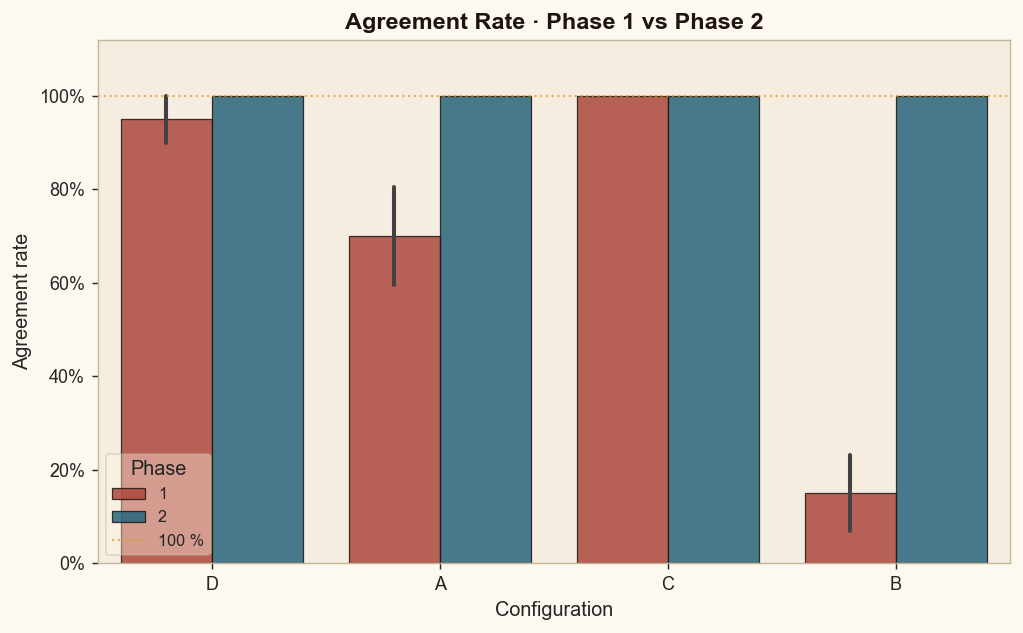

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=df, x="config", y="is_deal", hue="phase", ax=ax,
    errorbar="se", palette=RETRO_PALETTE[:2], alpha=0.85,
    edgecolor=INK, linewidth=0.7,
)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Agreement rate")
ax.set_xlabel("Configuration")
ax.set_title("Agreement Rate · Phase 1 vs Phase 2")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.axhline(1.0, color=RETRO_PALETTE[2], lw=1.2, ls=":", alpha=0.7, label="100 %")
ax.legend(title="Phase", framealpha=0.4)
fig.tight_layout()
fig.savefig(FIG_DIR / "agreement_rate.png", dpi=150)
plt.show()

### 3.2 Final price distribution (deals only)

Reference lines: seller's minimum acceptable price (€7000) and buyer's budget (€10000).

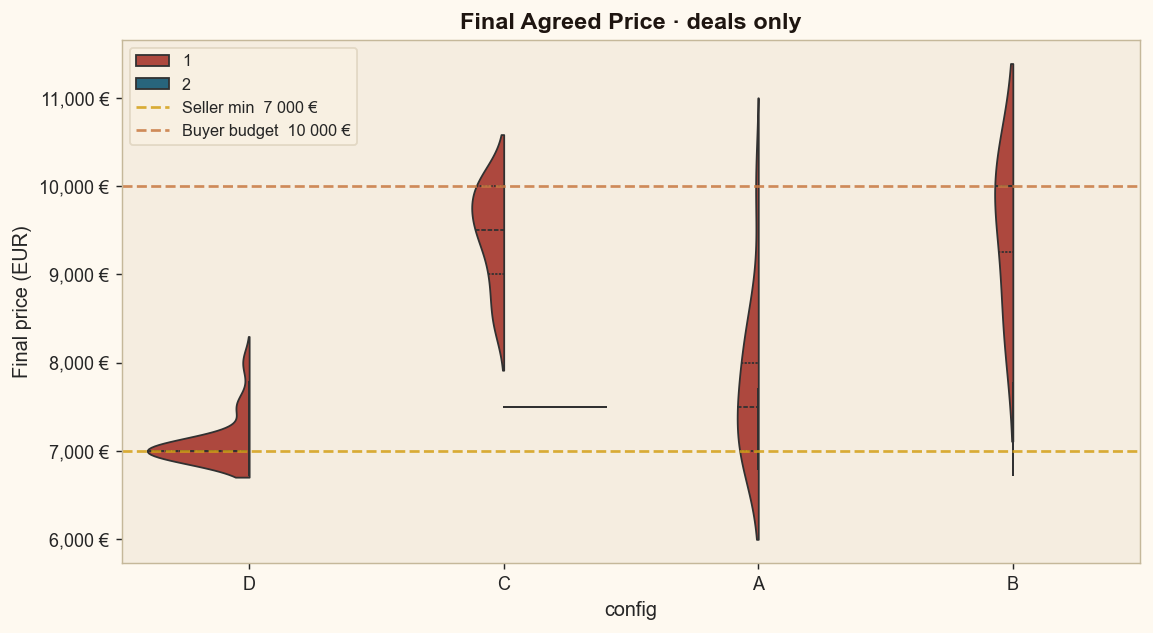

In [7]:
deals = df[df["outcome"] == "deal"].copy()
if len(deals) > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.violinplot(
        data=deals, x="config", y="final_price", hue="phase",
        split=True, inner="quart", ax=ax,
        palette=RETRO_PALETTE[:2], linewidth=1.0,
    )
    ax.axhline(7000,  ls="--", c=RETRO_PALETTE[2], lw=1.5, alpha=0.85, label="Seller min  7 000 €")
    ax.axhline(10000, ls="--", c=RETRO_PALETTE[4], lw=1.5, alpha=0.85, label="Buyer budget  10 000 €")
    ax.set_ylabel("Final price (EUR)")
    ax.set_title("Final Agreed Price · deals only")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f} €"))
    ax.legend(framealpha=0.4)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "price_distribution.png", dpi=150)
    plt.show()
else:
    print("No deals to plot.")

### 3.3 Information asymmetry — bug disclosure and discovery

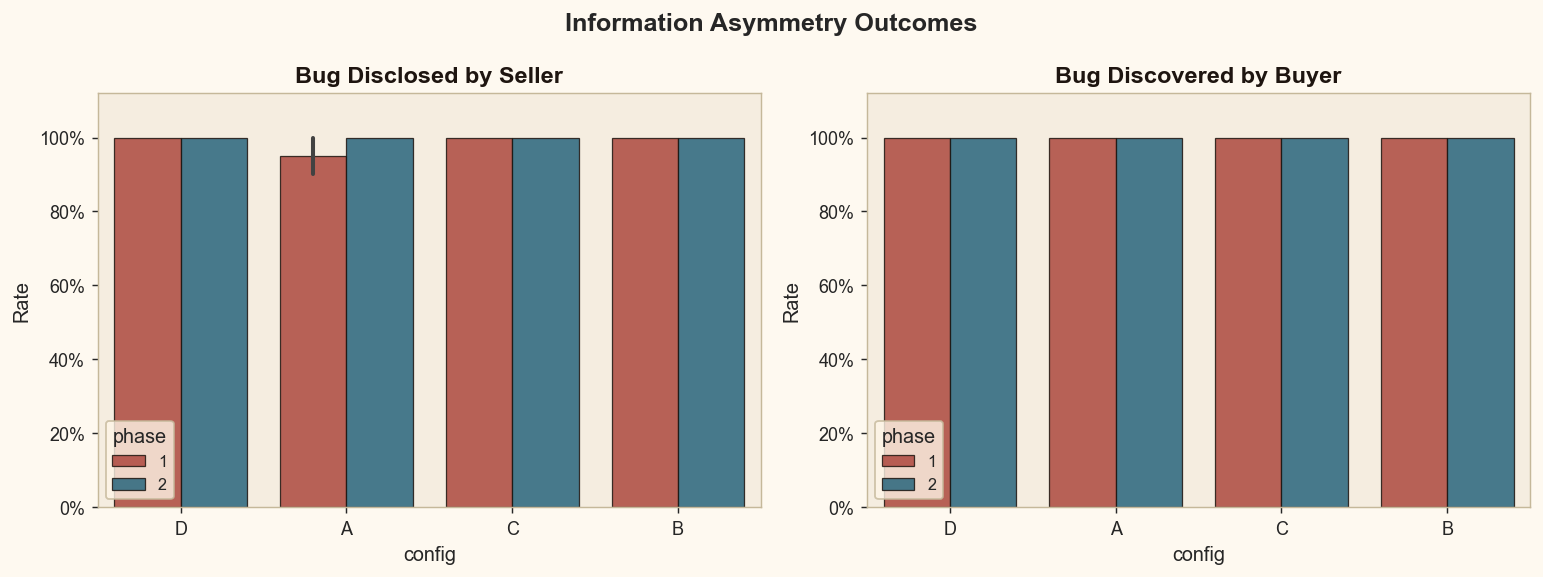

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
_bp_kw = dict(errorbar="se", palette=RETRO_PALETTE[:2], alpha=0.85,
              edgecolor=INK, linewidth=0.7)

sns.barplot(data=df, x="config", y="bug_disclosed",  hue="phase", ax=axes[0], **_bp_kw)
axes[0].set_title("Bug Disclosed by Seller")
axes[0].set_ylim(0, 1.12)
axes[0].set_ylabel("Rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

sns.barplot(data=df, x="config", y="bug_discovered", hue="phase", ax=axes[1], **_bp_kw)
axes[1].set_title("Bug Discovered by Buyer")
axes[1].set_ylim(0, 1.12)
axes[1].set_ylabel("Rate")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

fig.suptitle("Information Asymmetry Outcomes", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "bug_rates.png", dpi=150)
plt.show()

### 3.4 Turns to convergence

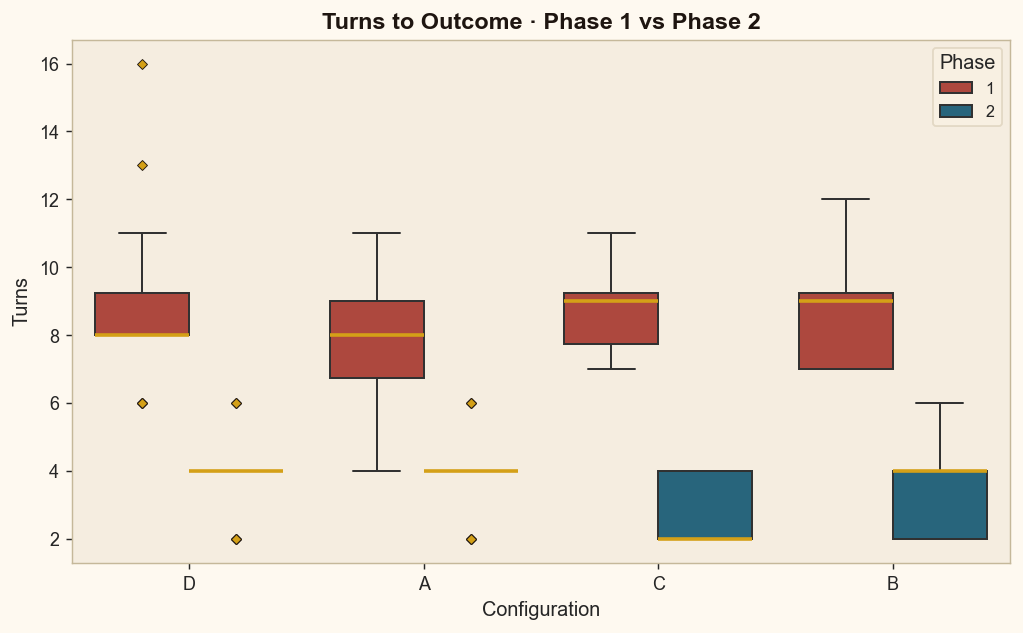

In [9]:
_fp = {"marker": "D", "markersize": 4,
       "markerfacecolor": RETRO_PALETTE[2], "markeredgecolor": INK,
       "markeredgewidth": 0.5}

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df, x="config", y="turns", hue="phase", ax=ax,
    palette=RETRO_PALETTE[:2], linewidth=1.1,
    flierprops=_fp, medianprops={"color": RETRO_PALETTE[2], "lw": 2},
)
ax.set_title("Turns to Outcome · Phase 1 vs Phase 2")
ax.set_ylabel("Turns")
ax.set_xlabel("Configuration")
ax.legend(title="Phase", framealpha=0.4)
fig.tight_layout()
fig.savefig(FIG_DIR / "turns.png", dpi=150)
plt.show()

## 4. Concessions — does behaviour shift from Phase 1 to Phase 2?

`seller_concession_count` = number of decreasing seller price mentions;
`buyer_concession_count`  = number of increasing buyer price mentions.

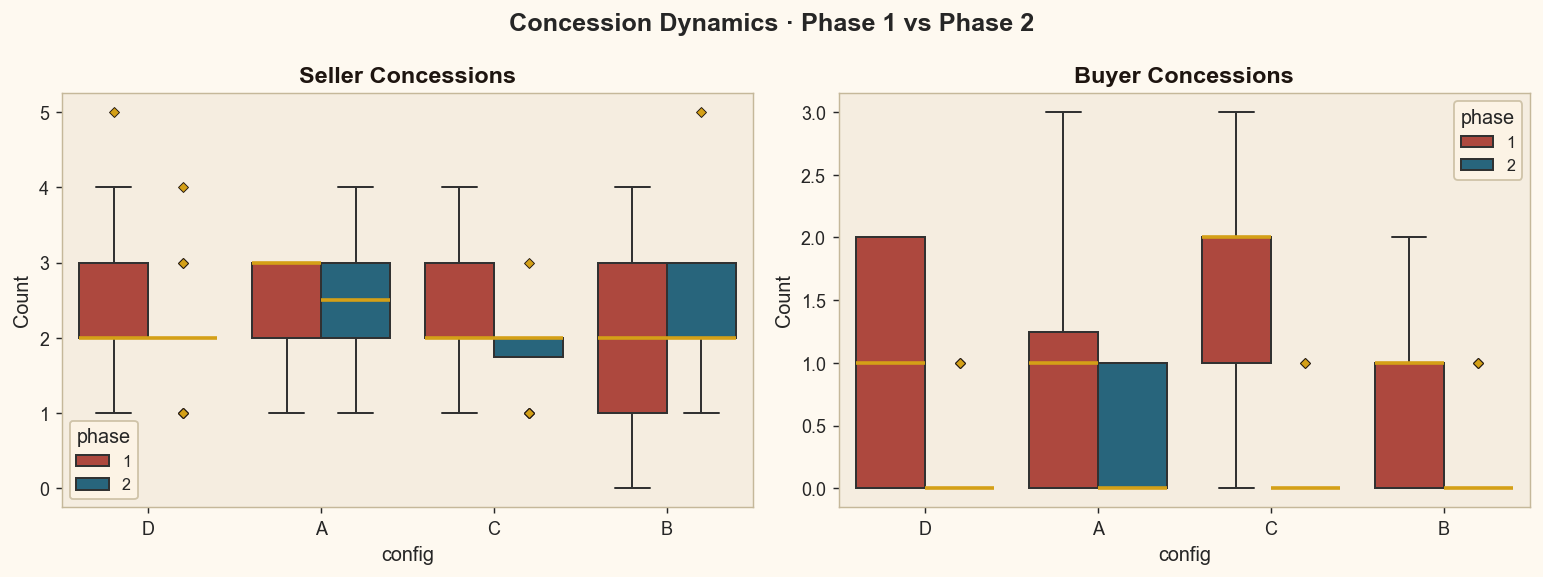

In [10]:
_fp = {"marker": "D", "markersize": 4,
       "markerfacecolor": RETRO_PALETTE[2], "markeredgecolor": INK,
       "markeredgewidth": 0.5}
_bp_kw = dict(palette=RETRO_PALETTE[:2], linewidth=1.1, flierprops=_fp,
              medianprops={"color": RETRO_PALETTE[2], "lw": 2})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=df, x="config", y="seller_concession_count", hue="phase", ax=axes[0], **_bp_kw)
axes[0].set_title("Seller Concessions")
axes[0].set_ylabel("Count")

sns.boxplot(data=df, x="config", y="buyer_concession_count",  hue="phase", ax=axes[1], **_bp_kw)
axes[1].set_title("Buyer Concessions")
axes[1].set_ylabel("Count")

fig.suptitle("Concession Dynamics · Phase 1 vs Phase 2", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "concessions.png", dpi=150)
plt.show()

## 5. Pragmatic adaptation — LLM-judge per-turn scoring

Each turn is scored 1–3 by an independent DeepSeek-R1 call: is the move *appropriate given the dialogue so far*?

This is **expensive** (≈ 1 API call per turn × all turns × all sessions). We cache the result to `data/processed/<run_id>_judge.json` so it is computed at most once per run.

In [11]:
from src.utils.deepseek_client import DeepSeekClient
from src.evaluation.qualitative import LLMJudge

JUDGE_CACHE_DIR = Path("data/processed")
JUDGE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def judge_run(run_id: str, sample_size: int | None = None) -> pd.DataFrame:
    """Return a per-turn DataFrame with LLM-judge scores for an entire run.

    Caches results to disk. Set `sample_size` to limit cost (random sessions per config).
    """
    cache = JUDGE_CACHE_DIR / f"{run_id}_judge.json"
    if cache.exists():
        return pd.DataFrame(json.loads(cache.read_text()))

    client = DeepSeekClient()
    judge = LLMJudge(client)
    rows: list[dict] = []
    run_dir = Path("data/raw") / run_id
    paths = sorted(run_dir.glob("*.json"))

    if sample_size is not None:
        # Take up to `sample_size` sessions per config to keep cost predictable
        by_cfg: dict[str, list[Path]] = {}
        for p in paths:
            cfg = json.loads(p.read_text())["config"]
            by_cfg.setdefault(cfg, []).append(p)
        rng = np.random.default_rng(42)
        paths = [p for cfg in by_cfg for p in rng.choice(by_cfg[cfg], min(sample_size, len(by_cfg[cfg])), replace=False)]

    for p in paths:
        data = TranscriptLogger.load_session(str(p))
        scores = judge.score_transcript(data["transcript"])
        for s in scores:
            rows.append({
                "session_id": data["session_id"],
                "config":     data["config"],
                "phase":      data["phase"],
                **s,
            })
    cache.write_text(json.dumps(rows, indent=2))
    print(f"Cached -> {cache}")
    return pd.DataFrame(rows)

# To save cost during development, start with a small sample. Set sample_size=None for full coverage.
judge_df = pd.concat([
    judge_run(PHASE1_RUN_ID, sample_size=3),
    judge_run(PHASE2_RUN_ID, sample_size=3) if PHASE2_DIR.exists() else pd.DataFrame(),
], ignore_index=True)
judge_df.head()

,session_id,config,phase,turn,role,score,rationale
0,a734870e-67ee-4365-bf6c-e91426a42423,B,1,0,seller,2,The seller provides a clear initial offer with...
1,a734870e-67ee-4365-bf6c-e91426a42423,B,1,1,buyer,3,The buyer adaptively acknowledges the price bu...
2,a734870e-67ee-4365-bf6c-e91426a42423,B,1,2,seller,2,The seller acknowledges the buyer's concerns a...
3,a734870e-67ee-4365-bf6c-e91426a42423,B,1,3,buyer,3,The buyer adaptively probes the seller's evasi...
4,a734870e-67ee-4365-bf6c-e91426a42423,B,1,4,seller,2,The seller partially addresses buyer's risk an...


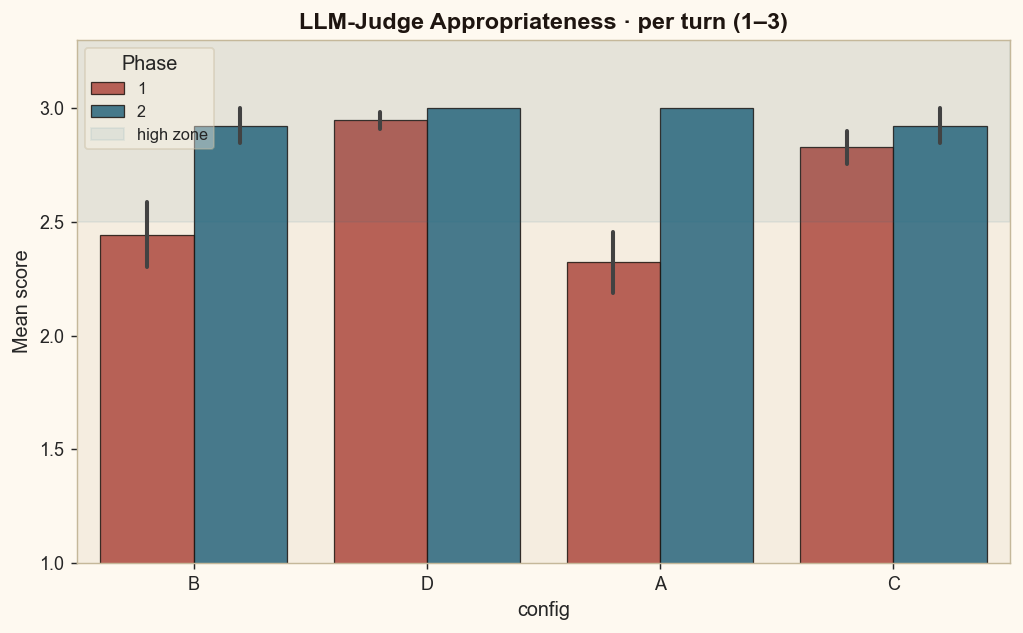

Mean score by config x phase x role:
config  phase  role  
A       1      buyer     2.93
               seller    1.82
        2      buyer     3.00
               seller    3.00
B       1      buyer     3.00
               seller    1.93
        2      buyer     3.00
               seller    2.88
C       1      buyer     3.00
               seller    2.67
        2      buyer     3.00
               seller    2.88
D       1      buyer     3.00
               seller    2.90
        2      buyer     3.00
               seller    3.00
Name: score, dtype: float64


In [12]:
if not judge_df.empty:
    judge_df["score"] = pd.to_numeric(judge_df["score"], errors="coerce")
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=judge_df, x="config", y="score", hue="phase", ax=ax,
        errorbar="se", palette=RETRO_PALETTE[:2], alpha=0.85,
        edgecolor=INK, linewidth=0.7,
    )
    ax.set_ylim(1, 3.3)
    ax.set_title("LLM-Judge Appropriateness · per turn (1–3)")
    ax.set_ylabel("Mean score")
    ax.axhspan(2.5, 3.3, color=RETRO_PALETTE[1], alpha=0.07, label="high zone")
    ax.legend(title="Phase", framealpha=0.4)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "llm_judge.png", dpi=150)
    plt.show()

    print("Mean score by config x phase x role:")
    print(judge_df.groupby(["config", "phase", "role"])["score"].mean().round(2))

## 6. Scripted imitation — cosine similarity (Phase 2 only)

For each Phase 2 session we compute the sentence-embedding cosine similarity between the full transcript and the few-shot example that was injected into the prompt for that role. A high similarity is evidence of **scripted imitation**; a low similarity indicates the agent **adapted** the tactic.

The first call downloads `all-MiniLM-L6-v2` (~80 MB) from HuggingFace; subsequent calls reuse the cached model.

In [13]:
if PHASE2_DIR.exists():
    tactics = PromptUpdater().load_tactics()

    sims = []
    for p in sorted(PHASE2_DIR.glob("*.json")):
        s = TranscriptLogger.load_session(str(p))
        # Each role is compared to the example it was conditioned on. We split the transcript
        # by role so seller turns are matched against the seller example, etc.
        for role in ("seller", "buyer"):
            role_turns = [t for t in s["transcript"] if t["role"] == role]
            if not role_turns or not tactics[role]["example"]:
                continue
            sim = compute_imitation_similarity(role_turns, tactics[role]["example"])
            sims.append({"session_id": s["session_id"], "config": s["config"], "role": role, "similarity": sim})
    sim_df = pd.DataFrame(sims)
    sim_df.head()
else:
    sim_df = pd.DataFrame()
    print("Phase 2 run not available — skipping cosine similarity.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SentenceTransformer loaded ✓  (cached for all subsequent calls)


In [14]:
# ── Stratified sample for human annotation of imitation threshold ─────────────

RANGES = [(0.60, 0.699), (0.70, 0.799), (0.80, 0.899), (0.90, 0.999)]
N_PER_BAND = 2

rng = np.random.default_rng(42)
sample_rows = []

for lo, hi in RANGES:
    band = sim_df[(sim_df["similarity"] >= lo) & (sim_df["similarity"] <= hi)]
    if band.empty:
        print(f"  [{lo:.2f}–{hi:.2f}]  no conversations found — skipping")
        continue
    n = min(N_PER_BAND, len(band))
    chosen = band.sample(n=n, random_state=42)
    sample_rows.append(chosen)
    print(f"  [{lo:.2f}–{hi:.2f}]  {n} conversation(s) selected")

sample_df = pd.concat(sample_rows).reset_index(drop=True)
print(f"\nTotal sample: {len(sample_df)} conversations\n")

# ── Load full transcript + few-shot example for each sampled row ──────────────
tactics = PromptUpdater().load_tactics()

for i, row in sample_df.iterrows():
    session_path = PHASE2_DIR / f"{row['session_id']}.json"
    session = TranscriptLogger.load_session(str(session_path))
    role_turns = [t for t in session["transcript"] if t["role"] == row["role"]]
    example = tactics[row["role"]]["example"]

    print("=" * 72)
    print(f"  #{i+1}  |  config={row['config']}  role={row['role']}  "
          f"similarity={row['similarity']:.4f}")
    print("=" * 72)

    print("\n── FEW-SHOT EXAMPLE (what the agent was shown) ──────────────────────")
    print(example)

    print(f"\n── AGENT TURNS IN THIS CONVERSATION ({len(role_turns)} turns) ───────────────────")
    for t in role_turns:
        print(f"\n  [Turn {t['turn']}]  {t['role'].upper()}")
        print(f"  {t['content']}")

    print()

  [0.60–0.70]  2 conversation(s) selected
  [0.70–0.80]  2 conversation(s) selected
  [0.80–0.90]  2 conversation(s) selected
  [0.90–1.00]  no conversations found — skipping

Total sample: 6 conversations

  #1  |  config=A  role=buyer  similarity=0.6387

── FEW-SHOT EXAMPLE (what the agent was shown) ──────────────────────
[Turn 3] BUYER: I appreciate the transparency, but "edge cases" is vague. Can you give me concrete examples of known issues or bugs that have been reported in production? If there are any recurring problems, that would directly affect the value of the software for us. We need a stable environment, not a beta test.
[Turn 4] SELLER: ...there is a known issue in our report export module—under very high load, it can occasionally cause data corruption...
[Turn 5] BUYER: That's a serious issue—data corruption in any module is unacceptable for a production environment... This drastically reduces the software's value to us. I'm willing to consider it only if you can offer 

As explained in the "human_calibration_cosine_similarity.docx", the threshold of cosine similarity for understanging whether a transcript is an imitation or adaptation will be chosen equal to 0.75. This is not a robust method and misclassifies many transcripts. Metrics like ROUGE-n could solve this problem.


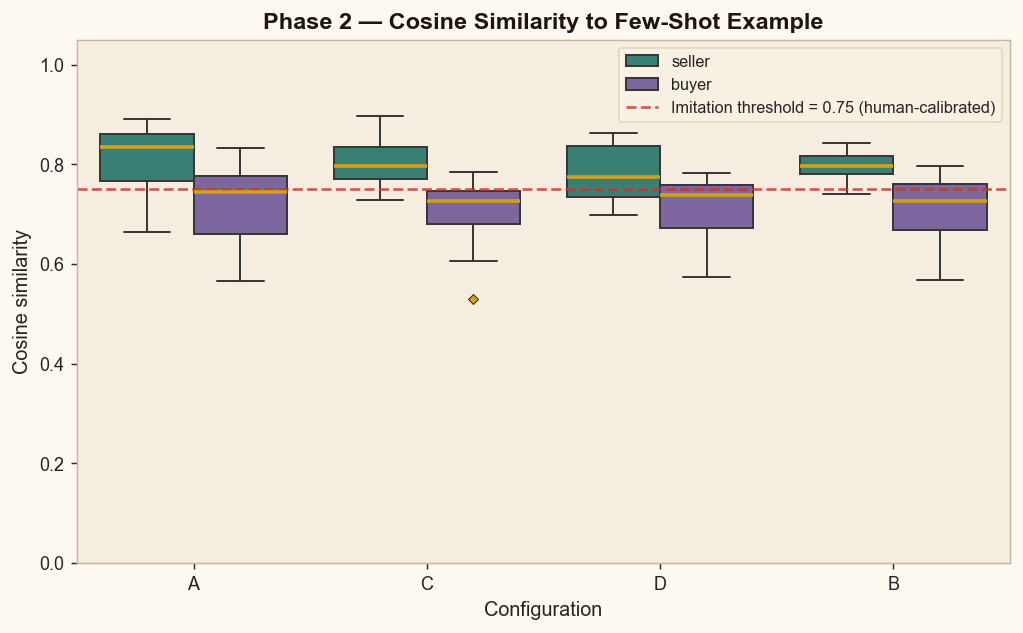

Mean similarity by config x role:
config  role  
A       buyer     0.717
        seller    0.813
B       buyer     0.710
        seller    0.796
C       buyer     0.707
        seller    0.802
D       buyer     0.719
        seller    0.782
Name: similarity, dtype: float64


In [15]:
if not sim_df.empty:
    _fp = {"marker": "D", "markersize": 4,
           "markerfacecolor": RETRO_PALETTE[2], "markeredgecolor": INK,
           "markeredgewidth": 0.5}
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(
        data=sim_df, x="config", y="similarity", hue="role", ax=ax,
        palette=[RETRO_PALETTE[3], RETRO_PALETTE[5]],
        linewidth=1.1, flierprops=_fp,
        medianprops={"color": RETRO_PALETTE[2], "lw": 2},
    )
    ax.set_ylim(0, 1.05)
    ax.set_title("Phase 2 — Cosine Similarity to Few-Shot Example")
    ax.set_ylabel("Cosine similarity")
    ax.set_xlabel("Configuration")
    ax.axhline(0.75, ls="--", c=RETRO_PALETTE[0], lw=1.5, alpha=0.8,
               label="Imitation threshold = 0.75 (human-calibrated)")
    ax.legend(framealpha=0.4)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "imitation_similarity.png", dpi=150)
    plt.show()

    print("Mean similarity by config x role:")
    print(sim_df.groupby(["config", "role"])["similarity"].mean().round(3))

## 7. Genuine reasoning — CoT structural analysis

We analyse the private chain-of-thought **per turn**, not on a concatenated blob.
The key intuition: the CoT at turn N should respond to what is visible in the
dialogue up to turn N-1. We therefore extract *anchor tokens* from the prior
turns (prices, percentages, content-bearing words) and measure how many of them
surface inside the CoT of turn N.

Three Level-1 metrics, all computed offline by `analyse_cot(cot_log, transcript)`:

- **grounding_score** — `anchors_found / anchors_available`. A high score means
  the reasoning is anchored to *this* dialogue; a low score means it is generic
  boilerplate that would fit any negotiation.
- **conditional_specificity** — among the conditional clauses in the CoT, what
  fraction contains at least one anchor. `"If they refuse 7500 again"` scores
  high; `"If I push too hard"` scores zero.
- **cot_length** — raw character count of the CoT, useful as a rough proxy of
  cognitive effort at each turn.

These metrics replace the previous flat `reasoning_score` (0–4), which was
saturated by boilerplate phrases (`"I need to ..."`) present in almost every
CoT and therefore not discriminative.

Section 7.2 adds a Level-2 LLM-based classifier (`CoTClassifier`) for two
additional dimensions: `context_specificity` (1–3) and `planning_depth` (1–3).
Results are cached on disk so this is paid for at most once.

Note: these are necessary but not sufficient signals. We cannot prove reasoning,
only show structural correlates.


In [16]:
# Build a PER-TURN DataFrame: one row per CoT entry, not per session.
# This is what unlocks the grounding / conditional-specificity metrics —
# at the session level they would average out the very signal we care about.

cot_turn_rows = []
for run_id, phase_label in [(PHASE1_RUN_ID, 1), (PHASE2_RUN_ID, 2)]:
    run_dir = Path("data/raw") / run_id
    if not run_dir.exists():
        continue
    for p in run_dir.glob("*.json"):
        s = TranscriptLogger.load_session(str(p))
        per_turn = analyse_cot(s["cot_log"], s["transcript"])
        for r in per_turn:
            cot_turn_rows.append({
                "session_id": s["session_id"],
                "config":     s["config"],
                "phase":      phase_label,
                **{k: v for k, v in r.items() if k != "indicator_counts"},
                **r["indicator_counts"],   # flatten the regex indicator dict
            })

cot_turn_df = pd.DataFrame(cot_turn_rows)

# Session-level rollup — used in the master table at §8 and for sanity checks.
cot_df = (
    cot_turn_df
    .groupby(["session_id", "config", "phase"], as_index=False)
    .agg(
        grounding_score=("grounding_score", "mean"),
        conditional_specificity=("conditional_specificity", "mean"),
        conditional_count=("conditional_count", "sum"),
        cot_total_chars=("cot_length", "sum"),
    )
)

print(f"Per-turn rows: {len(cot_turn_df)}   |   Session rows: {len(cot_df)}")
cot_turn_df.head()


Per-turn rows: 1126   |   Session rows: 160


,session_id,config,phase,turn,role,cot_length,anchors_available,anchors_found,grounding_score,conditional_count,conditional_anchored,conditional_specificity,conditional,history_reference,strategic_planning,goal_awareness
0,2945327a-0995-4726-aaf8-1ec2586c87fd,D,1,0,seller,421,0,0,0.0000,0,0,0.0,0,0,0,0
1,2945327a-0995-4726-aaf8-1ec2586c87fd,D,1,1,buyer,278,18,3,0.1667,0,0,0.0,0,0,1,0
2,2945327a-0995-4726-aaf8-1ec2586c87fd,D,1,2,seller,927,40,10,0.2500,1,1,1.0,1,0,0,0
3,2945327a-0995-4726-aaf8-1ec2586c87fd,D,1,3,buyer,142,66,4,0.0606,0,0,0.0,0,0,0,0
4,2945327a-0995-4726-aaf8-1ec2586c87fd,D,1,4,seller,931,81,14,0.1728,2,2,1.0,2,1,0,0


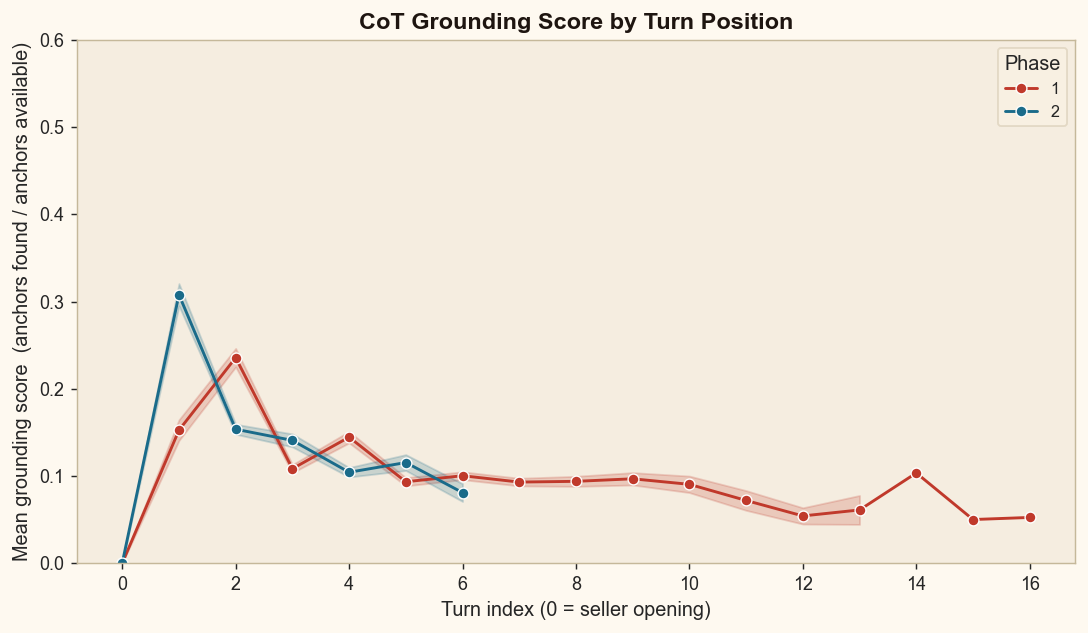

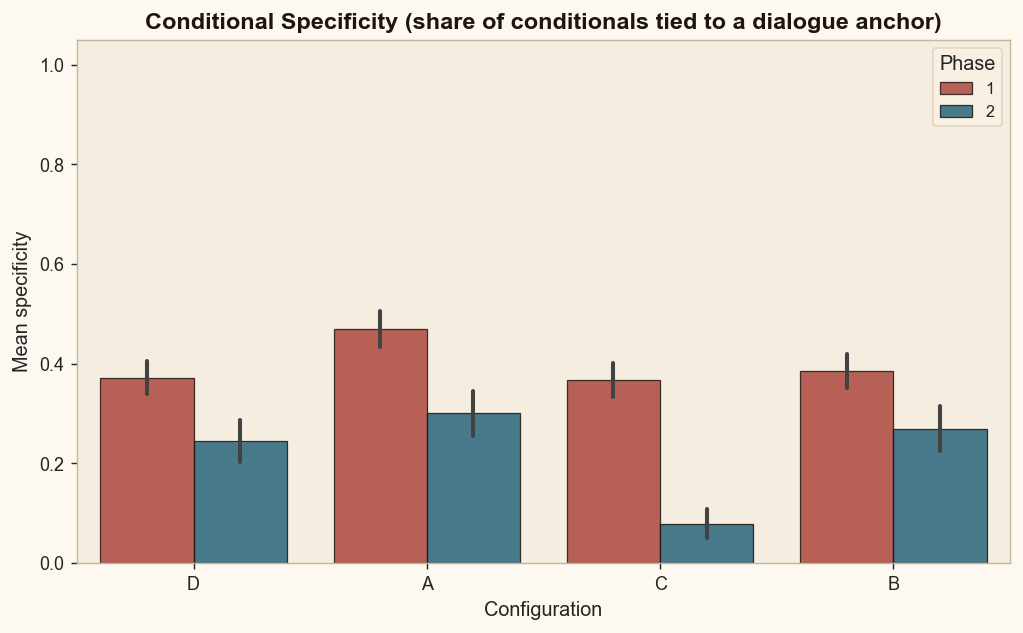

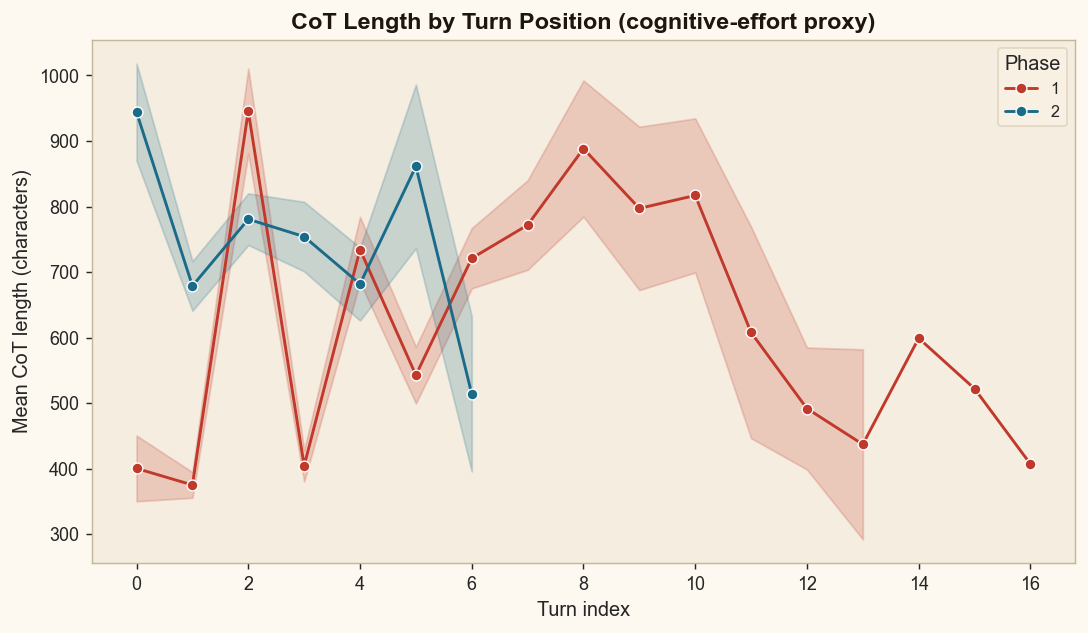

Mean Level-1 CoT metrics by config x phase:
              grounding_score  conditional_specificity  conditional_count  \
config phase                                                                
A      1                0.117                    0.470              1.163   
       2                0.147                    0.301              0.918   
B      1                0.104                    0.385              0.837   
       2                0.151                    0.270              0.968   
C      1                0.105                    0.368              0.885   
       2                0.138                    0.079              0.397   
D      1                0.122                    0.372              1.016   
       2                0.131                    0.245              0.459   

              cot_length  
config phase              
A      1         660.331  
       2         829.816  
B      1         552.684  
       2         856.495  
C      1         616.12

In [17]:
if not cot_turn_df.empty:
    # ── 7.1.a — Grounding score by turn position ──────────────────────────
    # Does the reasoning anchor itself to the dialogue more as the negotiation
    # unfolds? A rising curve = adaptive grounding. A flat curve near zero =
    # boilerplate reasoning that ignores accumulated context.
    fig, ax = plt.subplots(figsize=(8.5, 5))
    sns.lineplot(
        data=cot_turn_df, x="turn", y="grounding_score", hue="phase",
        palette=RETRO_PALETTE[:2], marker="o", linewidth=1.6, ax=ax,
        errorbar="se",
    )
    ax.set_title("CoT Grounding Score by Turn Position")
    ax.set_xlabel("Turn index (0 = seller opening)")
    ax.set_ylabel("Mean grounding score  (anchors found / anchors available)")
    ax.set_ylim(0, max(0.6, cot_turn_df["grounding_score"].quantile(0.95) + 0.05))
    ax.legend(title="Phase", framealpha=0.4)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "cot_grounding_by_turn.png", dpi=150)
    plt.show()

    # ── 7.1.b — Conditional specificity by config × phase ─────────────────
    # Among conditional clauses in the CoT, what share refers to a specific
    # anchor from THIS dialogue? Replaces the old `reasoning_score`.
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=cot_turn_df, x="config", y="conditional_specificity", hue="phase", ax=ax,
        errorbar="se", palette=RETRO_PALETTE[:2], alpha=0.85,
        edgecolor=INK, linewidth=0.7,
    )
    ax.set_title("Conditional Specificity (share of conditionals tied to a dialogue anchor)")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Mean specificity")
    ax.set_xlabel("Configuration")
    ax.legend(title="Phase", framealpha=0.4)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "cot_conditional_specificity.png", dpi=150)
    plt.show()

    # ── 7.1.c — CoT length by turn position ───────────────────────────────
    # Raw cognitive-effort proxy. We expect a bump around the turns where the
    # bug surfaces and the agents have to decide what to do with it.
    fig, ax = plt.subplots(figsize=(8.5, 5))
    sns.lineplot(
        data=cot_turn_df, x="turn", y="cot_length", hue="phase",
        palette=RETRO_PALETTE[:2], marker="o", linewidth=1.6, ax=ax,
        errorbar="se",
    )
    ax.set_title("CoT Length by Turn Position (cognitive-effort proxy)")
    ax.set_xlabel("Turn index")
    ax.set_ylabel("Mean CoT length (characters)")
    ax.legend(title="Phase", framealpha=0.4)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "cot_length_by_turn.png", dpi=150)
    plt.show()

    print("Mean Level-1 CoT metrics by config x phase:")
    print(cot_turn_df.groupby(["config", "phase"])[
        ["grounding_score", "conditional_specificity",
         "conditional_count", "cot_length"]
    ].mean().round(3))


### 7.2 Level-2 — LLM-based per-turn classifier

An independent `deepseek-chat` call rates each CoT on two 1–3 dimensions:
`context_specificity` (does the reasoning reference events/numbers from this
dialogue?) and `planning_depth` (does it weigh multiple future scenarios?).

Results are cached to `data/processed/<run_id>_cot_llm.json`, so this is paid
for at most once per run. Set `sample_size=None` for full coverage; 

The high-quadrant (high specificity + high planning depth) is the structural
fingerprint we associate with genuine reasoning.


In [23]:
from src.evaluation.qualitative import CoTClassifier

# `CoTClassifier.classify_run` caches to data/processed/<run_id>_cot_llm.json.
# Bump `sample_size` (or set it to None for the full run) once you are happy
# with the pilot output. Cost is roughly $0.005 per session at sample_size=None.
cot_classifier = CoTClassifier()

cot_llm_df = pd.concat([
    cot_classifier.classify_run(PHASE1_RUN_ID, sample_size=None),
    cot_classifier.classify_run(PHASE2_RUN_ID, sample_size=None) if PHASE2_DIR.exists() else pd.DataFrame(),
], ignore_index=True)

if not cot_llm_df.empty:
    cot_llm_df["context_specificity"] = pd.to_numeric(cot_llm_df["context_specificity"], errors="coerce")
    cot_llm_df["planning_depth"]      = pd.to_numeric(cot_llm_df["planning_depth"], errors="coerce")
cot_llm_df.head()


Cached -> data/processed/full_phase1_cot_llm.json
Cached -> data/processed/full_phase2_cot_llm.json


,session_id,config,phase,turn,role,context_specificity,planning_depth,evidence
0,0024cca8-7227-42fa-b364-91b02d4daff7,B,1,0,seller,1,1,"The reasoning is fully generic, mentioning onl..."
1,0024cca8-7227-42fa-b364-91b02d4daff7,B,1,1,buyer,2,1,The CoT mentions the seller's opening price of...
2,0024cca8-7227-42fa-b364-91b02d4daff7,B,1,2,seller,3,2,The CoT references the buyer's specific questi...
3,0024cca8-7227-42fa-b364-91b02d4daff7,B,1,3,buyer,2,1,The CoT mentions the price being above a max b...
4,0024cca8-7227-42fa-b364-91b02d4daff7,B,1,4,seller,2,2,The CoT mentions the buyer's questions about s...


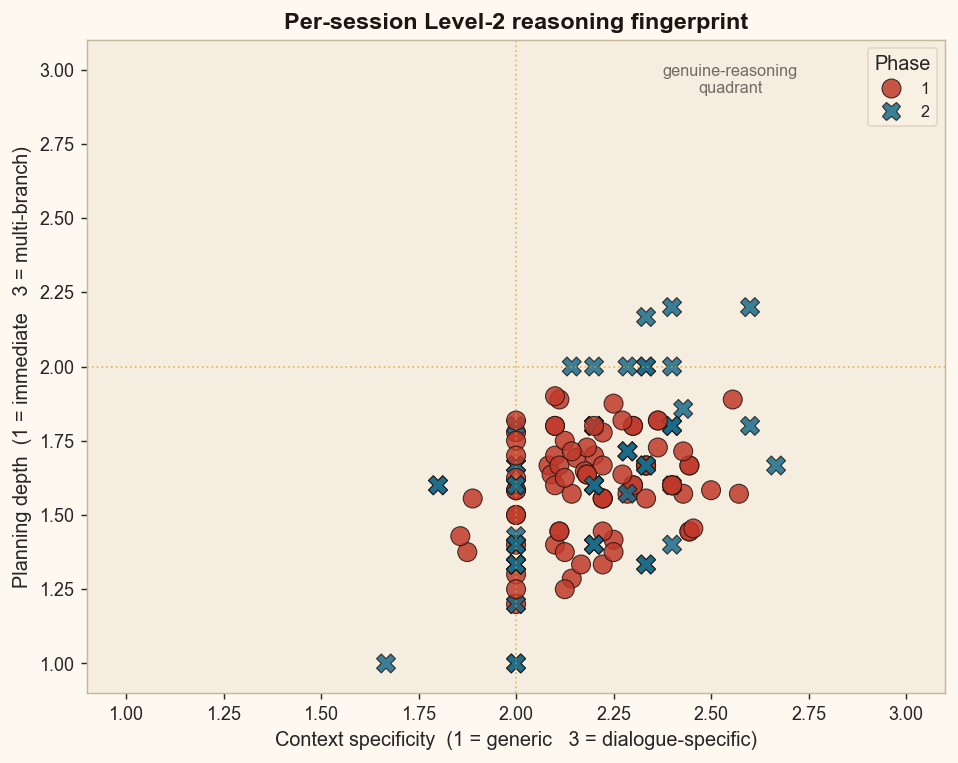

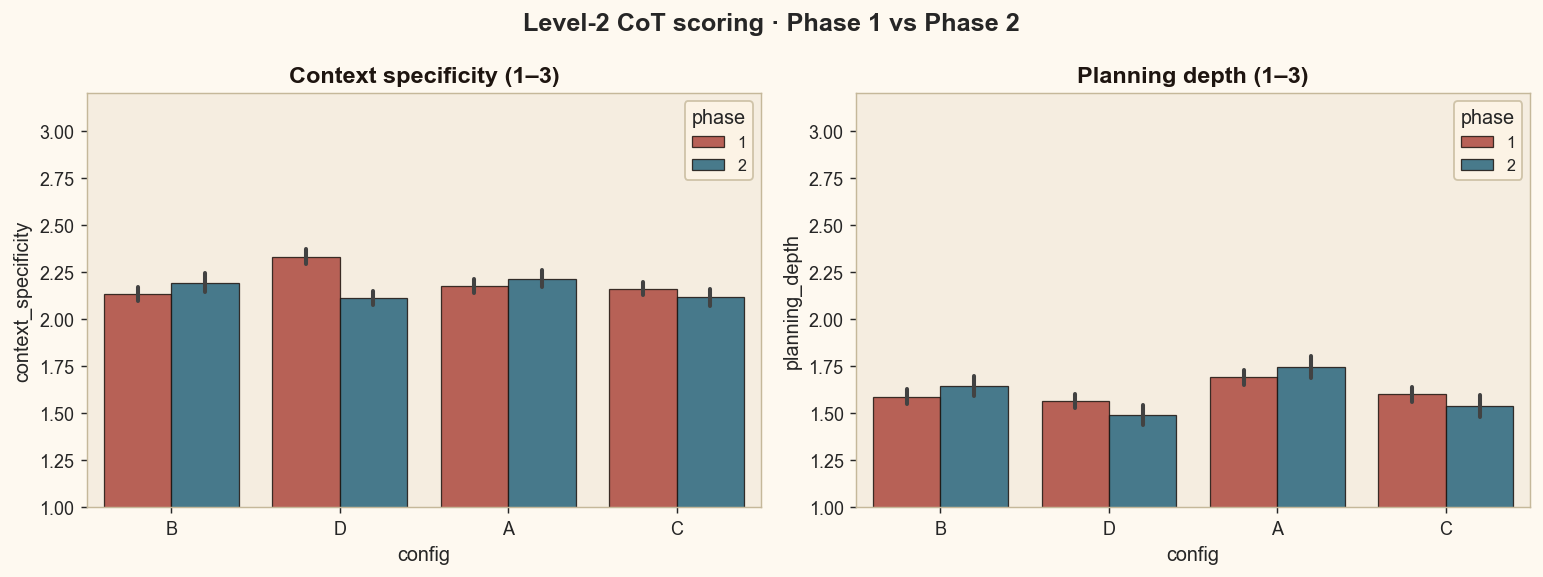

Mean Level-2 scores by config x phase:
              context_specificity  planning_depth
config phase                                     
A      1                     2.17            1.69
       2                     2.21            1.74
B      1                     2.13            1.59
       2                     2.19            1.65
C      1                     2.16            1.60
       2                     2.12            1.54
D      1                     2.33            1.56
       2                     2.11            1.49


In [24]:
if not cot_llm_df.empty:
    # Session-level means → one point per session in the scatter
    sess_llm = (
        cot_llm_df
        .dropna(subset=["context_specificity", "planning_depth"])
        .groupby(["session_id", "config", "phase"], as_index=False)
        .agg(specificity=("context_specificity", "mean"),
             planning=("planning_depth", "mean"))
    )

    # ── 7.2.a — Specificity vs planning depth scatter ─────────────────────
    fig, ax = plt.subplots(figsize=(7.5, 6))
    sns.scatterplot(
        data=sess_llm, x="specificity", y="planning", hue="phase",
        style="phase", palette=RETRO_PALETTE[:2], s=110,
        edgecolor=INK, linewidth=0.6, alpha=0.85, ax=ax,
    )
    ax.set_xlim(0.9, 3.1)
    ax.set_ylim(0.9, 3.1)
    ax.set_xlabel("Context specificity  (1 = generic   3 = dialogue-specific)")
    ax.set_ylabel("Planning depth  (1 = immediate   3 = multi-branch)")
    ax.set_title("Per-session Level-2 reasoning fingerprint")
    ax.axhline(2.0, ls=":", color=RETRO_PALETTE[2], lw=1.0, alpha=0.6)
    ax.axvline(2.0, ls=":", color=RETRO_PALETTE[2], lw=1.0, alpha=0.6)
    ax.text(2.55, 2.92, "genuine-reasoning\nquadrant", color=INK,
            fontsize=9, ha="center", alpha=0.6)
    ax.legend(title="Phase", framealpha=0.4)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "cot_llm_scatter.png", dpi=150)
    plt.show()

    # ── 7.2.b — Mean specificity / planning by config × phase ─────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    _bp_kw = dict(errorbar="se", palette=RETRO_PALETTE[:2], alpha=0.85,
                  edgecolor=INK, linewidth=0.7)
    sns.barplot(data=cot_llm_df, x="config", y="context_specificity",
                hue="phase", ax=axes[0], **_bp_kw)
    axes[0].set_title("Context specificity (1–3)")
    axes[0].set_ylim(1, 3.2)
    sns.barplot(data=cot_llm_df, x="config", y="planning_depth",
                hue="phase", ax=axes[1], **_bp_kw)
    axes[1].set_title("Planning depth (1–3)")
    axes[1].set_ylim(1, 3.2)
    fig.suptitle("Level-2 CoT scoring · Phase 1 vs Phase 2", fontsize=14, fontweight="bold")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "cot_llm_by_config.png", dpi=150)
    plt.show()

    print("Mean Level-2 scores by config x phase:")
    print(cot_llm_df.groupby(["config", "phase"])
                   [["context_specificity", "planning_depth"]].mean().round(2))


## 8. Master comparison table

One row per (config, phase), combining quantitative outcomes with CoT signals and (if computed) the LLM-judge mean.

In [25]:
master = summary.copy()

if not cot_df.empty:
    cot_agg = cot_df.groupby(["config", "phase"])[
        ["grounding_score", "conditional_specificity"]
    ].mean().reset_index()
    master = master.merge(cot_agg, on=["config", "phase"], how="left")

if "cot_llm_df" in globals() and not cot_llm_df.empty:
    llm_agg = (
        cot_llm_df
        .dropna(subset=["context_specificity", "planning_depth"])
        .groupby(["config", "phase"])
        [["context_specificity", "planning_depth"]]
        .mean().reset_index()
    )
    master = master.merge(llm_agg, on=["config", "phase"], how="left")

if not judge_df.empty:
    judge_agg = judge_df.groupby(["config", "phase"])["score"].mean().reset_index().rename(columns={"score": "judge_score"})
    master = master.merge(judge_agg, on=["config", "phase"], how="left")

if not sim_df.empty:
    sim_agg = sim_df.groupby(["config"])["similarity"].mean().reset_index().rename(columns={"similarity": "imitation_sim_phase2"})
    master = master.merge(sim_agg, on="config", how="left")

master.to_csv("data/results/master_table.csv", index=False)
print("Saved -> data/results/master_table.csv")
master


Saved -> data/results/master_table.csv


,config,phase,n_sessions,agreement_rate,mean_price,std_price,bug_disclosure_rate,bug_discovery_rate,mean_turns,std_turns,mean_msg_length,grounding_score,conditional_specificity,context_specificity,planning_depth,judge_score,imitation_sim_phase2
0,A,1,20,0.70,7750.00,849.21,0.95,1.0,7.90,1.80,53.22,0.116129,0.459432,2.174157,1.691011,2.322581,0.765047
1,A,2,20,1.00,7085.00,184.32,1.00,1.0,3.90,1.21,68.57,0.148911,0.286095,2.214286,1.744898,3.000000,0.765047
2,B,1,20,0.15,9500.00,866.03,1.00,1.0,8.80,1.51,56.28,0.104116,0.380269,2.132653,1.586735,2.444444,0.752840
3,B,2,20,1.00,7235.00,249.79,1.00,1.0,3.65,1.27,74.94,0.154442,0.245238,2.193548,1.645161,2.923077,0.752840
4,C,1,20,1.00,9455.00,532.60,1.00,1.0,8.60,1.23,54.62,0.105368,0.369407,2.161458,1.598958,2.827586,0.754827
5,C,2,20,1.00,7500.00,0.00,1.00,1.0,2.90,1.02,68.17,0.144954,0.079445,2.115385,1.538462,2.923077,0.754827
6,D,1,20,0.95,7105.26,267.65,1.00,1.0,8.65,2.46,61.13,0.124667,0.359285,2.331606,1.564767,2.945946,0.750182
7,D,2,20,1.00,7200.00,251.31,1.00,1.0,3.90,1.21,76.44,0.132458,0.248571,2.112245,1.489796,3.000000,0.750182


## 9. Where things were saved

All figures live in `data/results/figures/`; the two CSV tables are in `data/results/`.

- `agreement_rate.png`
- `price_distribution.png`
- `bug_rates.png`
- `turns.png`
- `concessions.png`
- `llm_judge.png` *(if the cell in §5 was executed)*
- `imitation_similarity.png` *(if Phase 2 is present)*
- `cot_grounding_by_turn.png` *(§7.1.a)*
- `cot_conditional_specificity.png` *(§7.1.b)*
- `cot_length_by_turn.png` *(§7.1.c)*
- `cot_llm_scatter.png` *(§7.2.a, if the LLM classifier was run)*
- `cot_llm_by_config.png` *(§7.2.b, if the LLM classifier was run)*
- `aggregated_summary.csv`
- `master_table.csv`
